In [642]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [643]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).reshape(-1, 1)

y = bias + weight * X

In [644]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


In [645]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [646]:
def plot_prediction(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, pred=None):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, s=10, c='b', label="Training Data")
    plt.scatter(test_data, test_labels, s=10, c='g', label="Testing Data")
    plt.grid(True)
    if pred is not None:
        plt.scatter(test_data, pred, s=10, c='r', label="Prediction")

    plt.legend()

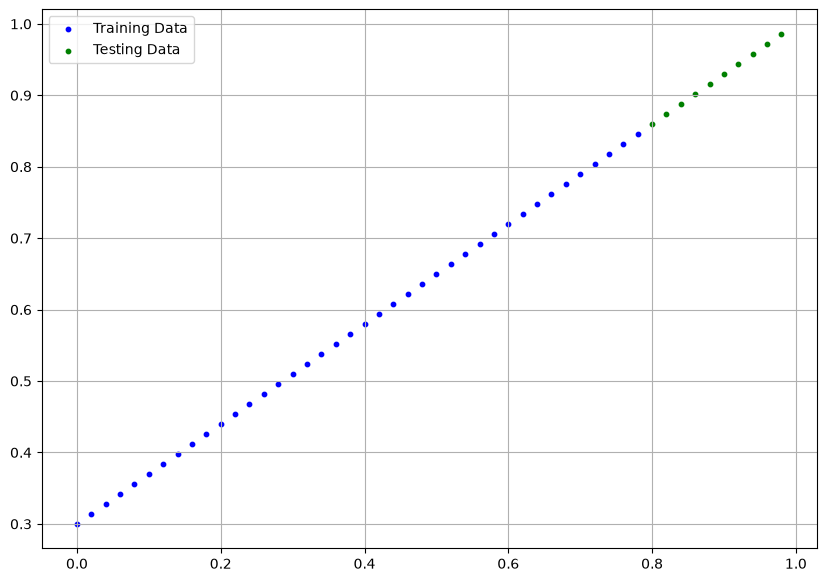

In [647]:
plot_prediction()

Our Model:
* Start with random parameters (weight & bias)
* Look at training data and adjust the random parameters to better represent (get closer) the ideal values (the weights and bias we used to create our data)

It uses:
* Gradient Descent
* Backpropogation

In [648]:
# Linear Regression Model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.bias + self.weight * x

# PyTorch model building essentials

- **`torch.nn`**
  Contains all of the building blocks for computational graphs (a neural network can be considered a computational graph).

- **`torch.nn.Parameter`**
  Defines what parameters our model should try and learn. Often a PyTorch layer from `torch.nn` will set these for us.

- **`torch.nn.Module`**
  The base class for all neural network modules. If you subclass it, you should override `forward()`.

- **`torch.optim`**
  This is where the optimizers in PyTorch live. They help with gradient descent.

- **`def forward()`**
  All `nn.Module` subclasses require you to override `forward()`. This method defines what happens in the forward computation.

### Making predictions using `torch.inference_mode()` or `torch.no_grad()`
- To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`
- When we pass data through our model, it's going to run it through the `forward`() method

In [649]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

with torch.inference_mode():
    y_pred = model_0(X_test)

y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [650]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

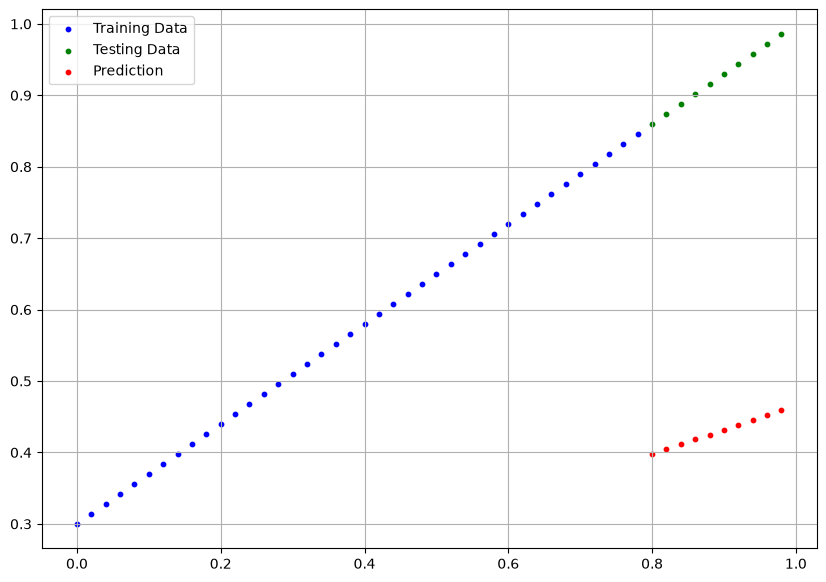

In [651]:
plot_prediction(pred=y_pred)

## 3. Train model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters.
Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your model's predictions are is to use a **loss function**.

- **Note:** Loss function may also be called *cost function* or *criterion* in different areas. For our case, we're going to refer to it as a loss function.

Things we need to train:

- **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
- **Optimizer:** Takes into account the lose of a model and adjust the model's parameters (weight and bias in our case) to improve the loss function.

And specifically for PyTorch, we need:
* A training loop
* A testing loop

### Set up Loss function and Optimizer

In [652]:
# Set up a loss function

loss_fun = nn.L1Loss()

# Set up an optimizer (Stochastic gradient descent)

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)


### Set up Training and testing loop
Steps for training loop:
1. Loop through the data
2. Forward pass (data moving through `forward()`)
3. Calculate the loss (compare the forward pass predictions to ground truth labels)
4. Optimizer zero grad
5. Loss backward - move backward through the network to calculate the gradients of each of the parameters of our model w.r.t. lose (**Backpropagation**)
6. Optimizer step - adjust parameters (**Gradient Descent**)

In [653]:
# An epoch is one loop through the data

torch.manual_seed(42)
epochs = 200
# Training
# Step 1: loop through data
for epoch in range(epochs):
    model_0.train()  # Set all parameters that require gradient descent to require gradient
    # 2. Forward pass
    y_pred_train = model_0(X_train)
    # 3. Calculate Loss
    loss = loss_fun(y_pred_train, y_train)
    # print(f"Loss: {loss}")
    # 4. Optimizer
    optimizer.zero_grad()
    # 5. Backpropagation
    loss.backward()
    # 6. Optimizer step
    optimizer.step()

    model_0.eval()  # turns off gradient tracking

    # print(model_0.state_dict())

In [654]:
with torch.inference_mode():
    y_pred_new = model_0(X_test)

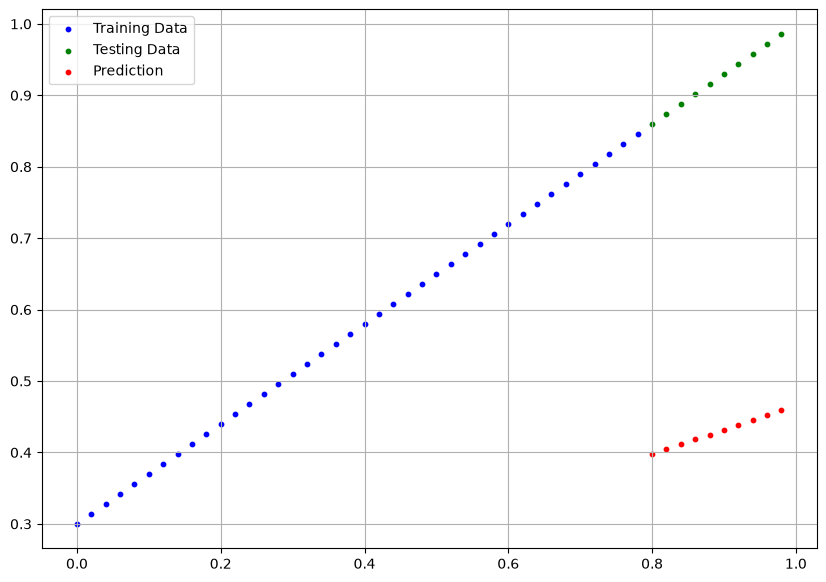

In [655]:
plot_prediction(pred=y_pred)

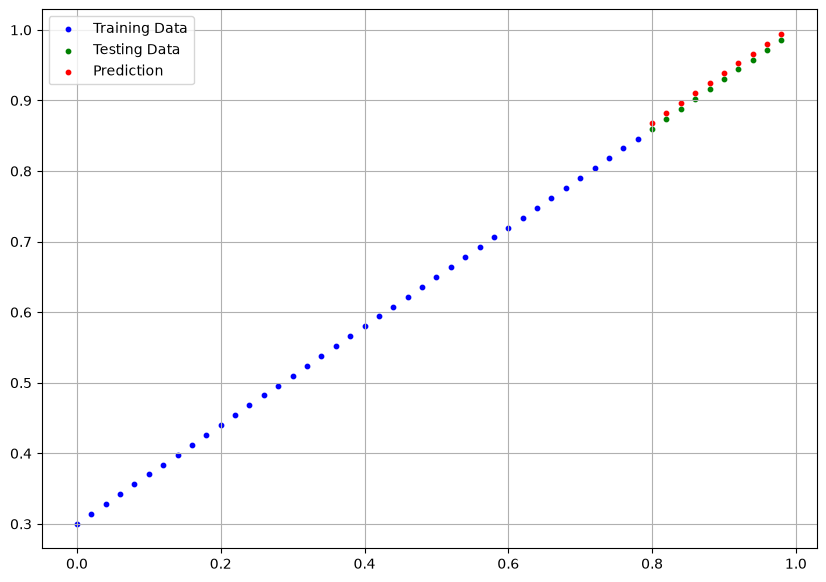

In [656]:
plot_prediction(pred=y_pred_new)

In [657]:
model_0.state_dict(), loss

(OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))]),
 tensor(0.0026, grad_fn=<MeanBackward0>))